# 40 - Daughter hierarchy length `l_max_ncdm` for warm daughters

nb37 (section 2b) found that `l_max_ncdm = 17`, the CLASS default, is too short for a warm daughter at large f̃:
at 10¹² GeV, f̃ = 0.5 it biased σ8_cb by −0.6% (Δχ² 0.2) at any grid, and at 10¹⁶ GeV it was negligible. That was
one point, on the old even grid. The fixed-mass chains (`chains/fixed_masses/k12.1a0.133`, CONNECT emulators trained
on full CLASS) all run at 17, and with `ncdm_fluid_approximation = 3` (none) the full hierarchy is evolved to today.
This notebook asks whether that matters.

- **1** maps the truncation error: Δχ² of `l_max_ncdm` = 17, 25, 35, 50 against 70, on a (mass, f̃) grid over the
  warm masses with 10¹⁴ GeV as a cold control, and checks the reference against 100.
- **2** sets it against the chains: the error at each chain's 95% and 99% f̃, and the f̃ above which each
  `l_max_ncdm` exceeds Δχ² = 0.1, i.e. how much of the f̃ ∈ [0, 0.999] training box is biased.
- **3** shows where in ℓ and k the error sits.
- **4** checks that the truncation error and the momentum-grid error are separate: the l_max error at 50 and at 200
  bins/decade, and the grid error left at s = 0.25 (nb38) for comparison.

`l_max_ncdm` is one setting for all ncdm species, so it also lengthens the neutrino hierarchy; section 1 includes a
f̃ = 10⁻⁶ row that isolates that part.

- **Settings:** each mass's `log.param` (κ = 12.1, a_t = 0.133, strategy 5, s = 0.25, DE sink on, 50 bins/decade),
  ΛCDM best fit of the 10¹⁴ GeV chain, fixed ω_dm,tot.
- **Δχ²:** the nb32/nb33/nb37 approximation (Planck-like CMB, 2.5% lensing amplitude, 1% DESI-like BAO, ΛCDM
  fixed): a sensitivity scale, not a likelihood. Tolerance 0.1.

Runs in parallel (`N_WORKERS` CLASS processes), about 15 min on 8 workers; cached in `40_cache.pkl`, delete it after
rebuilding CLASS.

In [1]:
import ast
import json
import multiprocessing as mp
import pickle
import queue
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


def show(df, formats):
    """display df with per-column format strings; missing values as '-'."""
    out = df.copy().astype(object)
    for col, f in formats.items():
        out[col] = [('-' if pd.isna(v) else f.format(v)) for v in df[col]]
    display(out)


def chain_settings(directory):
    """CLASS settings of one chain, as MontePython passes them (fixed ncdm parameters joined per species)."""
    species = {}
    settings = {}
    for line in open(directory/'log.param'):
        if line.startswith("data.parameters['") and '__' in line:
            name, idx = line.split("'")[1].rsplit('__', 1)
            value = ast.literal_eval(line.split('=', 1)[1].strip())[0]
            species.setdefault(name, {})[int(idx)] = value
        elif line.startswith('data.cosmo_arguments.update('):
            settings = ast.literal_eval(line.strip()[len('data.cosmo_arguments.update('):-1])
    for name, values in species.items():
        settings[name] = ', '.join('{:g}'.format(values[i]) for i in sorted(values))
    settings.pop('connect_model', None)
    settings.pop('m_acc_in_GeV')
    return settings


def chain_quantiles(directory, qs=(0.95, 0.99), burn_in=0.3):
    """f_tilde quantiles of one chain (flat omega_dm_tot, f_tilde)."""
    names = [line.split()[0] for line in open(next(directory.glob('*_.paramnames')))]
    blocks = []
    for path in sorted(directory.glob('*__*.txt')):
        block = pd.read_csv(path, sep=r'\s+', header=None, comment='#').to_numpy()
        blocks.append(block[int(burn_in*len(block)):])
    data = np.vstack(blocks)
    w, ft = data[:, 0], data[:, 2 + names.index('f_tilde')]
    order = np.argsort(ft)
    cdf = np.cumsum(w[order])
    return [float(np.interp(q*cdf[-1], cdf, ft[order])) for q in qs]


CHAINS = find_root()/'chains'/'fixed_masses'/'k12.1a0.133'
BF = read_bestfit(CHAINS/'14'/'14.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}
OMEGA_DM_TOT = BF['omega_dm_tot']
SETTINGS = chain_settings(CHAINS/'14')
for m in ('11', '12', '13'):
    assert chain_settings(CHAINS/m) == SETTINGS, m
SETTINGS.update({'omega_dm_tot': OMEGA_DM_TOT, 'k_pivot': 0.05})
print('settings:', SETTINGS)

QUANT = {float(m): chain_quantiles(CHAINS/m) for m in ('11', '12', '13', '14')}
print('chain f_tilde 95% / 99%:', ', '.join('{:g}: {:.4f} / {:.4f}'.format(m, *q) for m, q in QUANT.items()))

/opt/homebrew/Caskroom/miniforge/base/envs/accDM/lib/python3.12/site-packages/figkit/style.py:132: RuntimeWarning: text.usetex requested but dvipng not found on PATH; falling back to matplotlib mathtext. Install TeX Live or MiKTeX (and dvipng) for identical output, or pass usetex=False to silence this.
  usetex = bool(usetex) and latex_available()


settings: {'N_ncdm': 2, 'N_ur': 2.0308, 'accdm_q_log_share': 0.25, 'ncdm_fluid_approximation': 3, 'kappa_acc': 12.1, 'a_t_acc': 0.133, 'vary_Gamma_acc': 'yes', 'acc_de_sink': 'yes', 'gauge': 'synchronous', 'reionization_z_start_max': 80, 'evolver': 0, 'output': 'mPk, lCl, tCl, pCl', 'P_k_max_1/Mpc': 1.0, 'lensing': 'yes', 'l_max_scalars': 2508, 'm_ncdm': '0.06, 0.1', 'deg_ncdm': '1, 1', 'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 5', 'omega_dm_tot': 0.1176592, 'k_pivot': 0.05}
chain f_tilde 95% / 99%: 11: 0.0065 / 0.0094, 12: 0.0123 / 0.0179, 13: 0.0154 / 0.0226, 14: 0.0269 / 0.0392


In [2]:
LMAX = 2500
ELL = np.arange(2, LMAX + 1)
KK = np.logspace(-4, np.log10(0.9), 300)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
TIMEOUT = 1800.0                                                     # s per run
N_WORKERS = 8
CACHE = Path('40_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def params(log10m, f_tilde, **extra):
    return {**LCDM, **SETTINGS, 'l_max_scalars': 2508, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, **extra}


def run(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    out['finite'] = bool(all(np.all(np.isfinite(v)) for v in out.values()))
    return out


def _child(p, q):
    try:
        q.put(run(p))
    except Exception as err:
        q.put({'error': '{}: {}'.format(type(err).__name__, err)})


def run_isolated(p):
    """run(p) in a forked child, so a crash or hang becomes an error entry."""
    ctx = mp.get_context('fork')
    q = ctx.Queue()
    proc = ctx.Process(target=_child, args=(p, q))
    t0 = time.time()
    proc.start()
    out = None
    while out is None:
        try:
            out = q.get(timeout=1.0)
        except queue.Empty:
            if not proc.is_alive():
                try:
                    out = q.get(timeout=2.0)
                except queue.Empty:
                    out = {'error': 'CLASS process died, exit code {}'.format(proc.exitcode)}
            elif time.time() - t0 > TIMEOUT:
                proc.kill()
                out = {'error': 'timeout after {:.0f} s'.format(TIMEOUT)}
    proc.join()
    out['sec'] = time.time() - t0
    return out


def key(p):
    return json.dumps(p, sort_keys=True)


def run_all(ps):
    """Cached results of the runs ps, computing the missing ones N_WORKERS at a time."""
    todo = list({key(p): p for p in ps if key(p) not in cache}.values())
    if todo:
        t0 = time.time()
        with ThreadPoolExecutor(N_WORKERS) as pool:
            for i, (p, out) in enumerate(zip(todo, pool.map(run_isolated, todo))):
                cache[key(p)] = out
                if (i + 1) % N_WORKERS == 0 or i + 1 == len(todo):
                    CACHE.write_bytes(pickle.dumps(cache))
        print('{} new runs in {:.0f} s'.format(len(todo), time.time() - t0))
    return [cache[key(p)] for p in ps]


def ok(out):
    return 'error' not in out and out['finite']


# nb33 Delta chi2
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)
DCHI2_TOL = 0.1


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def compare(a, b):
    """Delta chi2 parts, max |dP_cb/P_cb| and d sigma8_cb of run a against run b."""
    return {**chi2_parts(a, b), 'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1))),
            'dsigma8': a['sigma8_cb']/b['sigma8_cb'] - 1}

## 1. Truncation error over (mass, f̃)

Each point runs `l_max_ncdm` = 17 (default), 25, 35, 50 and the reference 70, at the chains' 50 bins/decade.
*Signal* is Δχ² of the reference against f̃ = 10⁻⁶ at the same `l_max_ncdm`; the f̃ = 10⁻⁶ row is the neutrino-only
truncation error. Three hard points rerun 100 to check the reference.

In [3]:
MASSES = [11, 11.5, 12, 12.5, 13, 14]
F_GRID = [0.003, 0.01, 0.03, 0.1, 0.3, 0.5, 0.9]
LMAXS = [17, 25, 35, 50]
REF = 70
F_NULL = 1e-6
REF_CHECK = [(11, 0.1), (11, 0.9), (12, 0.9)]

jobs = {}
for lm in MASSES:
    for ft in F_GRID:
        for L in LMAXS + [REF]:
            jobs[(lm, ft, L)] = params(lm, ft, l_max_ncdm=L)
for L in LMAXS + [REF]:
    jobs[(14, F_NULL, L)] = params(14, F_NULL, l_max_ncdm=L)
for lm, ft in REF_CHECK:
    jobs[(lm, ft, 100)] = params(lm, ft, l_max_ncdm=100)
res = dict(zip(jobs, run_all(list(jobs.values()))))
bad = {k: v.get('error', 'NON-FINITE')[-150:] for k, v in res.items() if not ok(v)}
print('{} runs, {} failed'.format(len(res), len(bad)))
for k, v in bad.items():
    print(' ', k, v)

218 new runs in 4310 s
218 runs, 0 failed


In [4]:
null = res[(14, F_NULL, REF)]
rows = []
for lm, ft in [(14, F_NULL)] + [(lm, ft) for lm in MASSES for ft in F_GRID]:
    ref = res[(lm, ft, REF)]
    row = {'log10m': lm, 'f_tilde': ft, 'signal': chi2_parts(ref, null)['total'] if ft != F_NULL else np.nan}
    for L in LMAXS:
        row['dchi2 {}'.format(L)] = compare(res[(lm, ft, L)], ref)['total']
    c17 = compare(res[(lm, ft, 17)], ref)
    row.update({'17: cmb': c17['cmb'], '17: lens': c17['lens'], '17: bao': c17['bao'],
                '17: max dPcb': c17['dpk'], '17: dsigma8_cb': c17['dsigma8'],
                'time 17 [s]': res[(lm, ft, 17)]['sec'], 'time 70 [s]': ref['sec']})
    rows.append(row)
table = pd.DataFrame(rows).set_index(['log10m', 'f_tilde'])
show(table, {**{c: '{:.2e}' for c in table.columns}, '17: dsigma8_cb': '{:+.1e}', 'time 17 [s]': '{:.0f}',
             'time 70 [s]': '{:.0f}'})

print('reference error, {} vs 100:'.format(REF))
for lm, ft in REF_CHECK:
    c = compare(res[(lm, ft, REF)], res[(lm, ft, 100)])
    c17 = compare(res[(lm, ft, 17)], res[(lm, ft, 100)])
    print('  log10m {:g}, f_tilde {:g}: dchi2 = {:.2e}, dsigma8_cb = {:+.1e}  (17 vs 100: dchi2 = {:.2e})'.format(
        lm, ft, c['total'], c['dsigma8'], c17['total']))

signal  dchi2 17  dchi2 25  dchi2 35  dchi2 50   17: cmb  \
log10m f_tilde                                                                
14.0   0.000001         -  8.76e-04  5.09e-07  6.58e-09  1.88e-10  8.74e-04   
11.0   0.003000  1.16e+00  9.49e-04  1.61e-05  8.42e-06  9.96e-07  9.17e-04   
       0.010000  1.29e+01  1.25e-03  1.54e-04  8.93e-05  1.09e-05  1.01e-03   
       0.030000  1.15e+02  3.14e-03  1.34e-03  7.89e-04  1.00e-04  1.19e-03   
       0.100000  1.26e+03  3.21e-02  1.78e-02  9.37e-03  1.27e-03  1.05e-02   
       0.300000  1.31e+04  7.77e-01  2.74e-01  1.15e-01  1.69e-02  5.92e-01   
       0.500000  4.53e+04  2.62e+00  9.20e-01  3.21e-01  3.91e-02  2.25e+00   
       0.900000  2.12e+05  8.57e+00  2.53e+00  6.90e-01  7.30e-02  8.45e+00   
11.5   0.003000  1.81e-01  9.20e-04  6.88e-06  2.81e-06  2.92e-07  9.02e-04   
       0.010000  2.00e+00  1.09e-03  5.98e-05  2.92e-05  3.15e-06  9.74e-04   
       0.030000  1.77e+01  2.06e-03  5.04e-04  2.58e-04  2.81e-05  1.21e-03   
       0.100000  1.91e+02  1.14e-02  5.53e-03  2.90e-03  3.16e-04  2.29e-03   
       0.300000  1.88e+03  1.01e-01  5.38e-02  2.64e-02  3.02e-03  1.78e-02   
       0.500000  6.63e+03  3.18e-01  1.49e-01  6.82e-02  7.91e-03  1.14e-01   
       0.900000  3.58e+04  8.69e-01  2.84e-01  9.12e-02  9.96e-03  7.54e-01   
12.0   0.003000  7.72e-02  9.08e-04  3.70e-06  8.43e-07  7.24e-08  8.95e-04   
       0.010000  8.55e-01  1.03e-03  2.83e-05  8.28e-06  7.51e-07  9.46e-04   
       0.030000  7.49e+00  1.73e-03  2.31e-04  7.19e-05  6.65e-06  1.12e-03   
       0.100000  7.68e+01  8.39e-03  2.52e-03  7.92e-04  7.41e-05  1.87e-03   
       0.300000  6.11e+02  6.52e-02  2.27e-02  6.96e-03  6.73e-04  4.36e-03   
       0.500000  1.79e+03  1.64e-01  5.69e-02  1.69e-02  1.71e-03  1.01e-02   
       0.900000  8.49e+03  1.72e-01  5.19e-02  1.39e-02  2.30e-03  7.40e-02   
12.5   0.003000  6.01e-02  8.97e-04  1.57e-06  1.67e-07  8.90e-09  8.88e-04   
       0.010000  7.03e-01  9.68e-04  8.44e-06  1.38e-06  8.01e-08  9.22e-04   
       0.030000  5.83e+00  1.33e-03  6.17e-05  1.13e-05  6.74e-07  1.03e-03   
       0.100000  5.80e+01  4.52e-03  6.43e-04  1.20e-04  7.19e-06  1.43e-03   
       0.300000  4.03e+02  2.99e-02  5.52e-03  1.01e-03  6.11e-05  2.56e-03   
       0.500000  9.19e+02  7.07e-02  1.32e-02  2.34e-03  1.49e-04  4.25e-03   
       0.900000  2.69e+03  5.90e-02  1.07e-02  1.95e-03  2.10e-04  2.08e-02   
13.0   0.003000  5.18e-02  8.87e-04  7.46e-07  2.86e-08  1.15e-09  8.82e-04   
       0.010000  5.70e-01  9.17e-04  1.80e-06  1.42e-07  6.51e-09  9.01e-04   
       0.030000  4.98e+00  1.04e-03  8.61e-06  9.19e-07  4.52e-08  9.57e-04   
       0.100000  4.99e+01  1.85e-03  7.53e-05  8.64e-06  4.36e-07  1.14e-03   
       0.300000  3.36e+02  7.26e-03  5.82e-04  6.47e-05  3.27e-06  1.52e-03   
       0.500000  7.03e+02  1.48e-02  1.30e-03  1.38e-04  7.14e-06  1.68e-03   
       0.900000  1.39e+03  1.06e-02  9.96e-04  8.32e-05  6.46e-06  3.06e-03   
14.0   0.003000  2.89e-02  8.78e-04  5.19e-07  7.12e-09  2.03e-10  8.75e-04   
       0.010000  3.19e-01  8.82e-04  5.46e-07  8.70e-09  2.33e-10  8.79e-04   
       0.030000  2.80e+00  8.93e-04  6.24e-07  1.28e-08  3.77e-10  8.90e-04   
       0.100000  2.84e+01  9.30e-04  9.66e-07  3.23e-08  1.35e-09  9.22e-04   
       0.300000  1.97e+02  1.01e-03  2.22e-06  9.40e-08  4.98e-09  9.87e-04   
       0.500000  4.19e+02  1.05e-03  3.07e-06  1.12e-07  6.44e-09  1.01e-03   
       0.900000  7.82e+02  1.01e-03  1.50e-06  2.53e-08  2.72e-09  9.92e-04   

                 17: lens   17: bao 17: max dPcb 17: dsigma8_cb time 17 [s]  \
log10m f_tilde                                                                
14.0   0.000001  2.00e-06  0.00e+00     8.88e-04       -6.7e-05          80   
11.0   0.003000  3.18e-05  0.00e+00     9.79e-04       -1.1e-04          48   
       0.010000  2.41e-04  0.00e+00     1.19e-03       -2.3e-04          49   
       0.030000  1.95e-03  0.00e+00     1.81e-03       -5.5e-04     

reference error, 70 vs 100:
  log10m 11, f_tilde 0.1: dchi2 = 3.97e-04, dsigma8_cb = +3.6e-04  (17 vs 100: dchi2 = 2.78e-02)
  log10m 11, f_tilde 0.9: dchi2 = 2.26e-02, dsigma8_cb = +6.4e-03  (17 vs 100: dchi2 = 9.22e+00)
  log10m 12, f_tilde 0.9: dchi2 = 3.20e-04, dsigma8_cb = +1.8e-03  (17 vs 100: dchi2 = 1.67e-01)


## 2. Against the chains

Left: Δχ² of `l_max_ncdm = 17` against f̃, with each chain's 95% (star) and 99% (diamond) f̃. Right: the same
relative to the accDM signal. The table gives, per mass and `l_max_ncdm`, the f̃ above which Δχ² exceeds 0.1
(log-log interpolation on the grid), and the share of the flat f̃ ∈ [0, 0.999] training box above it.

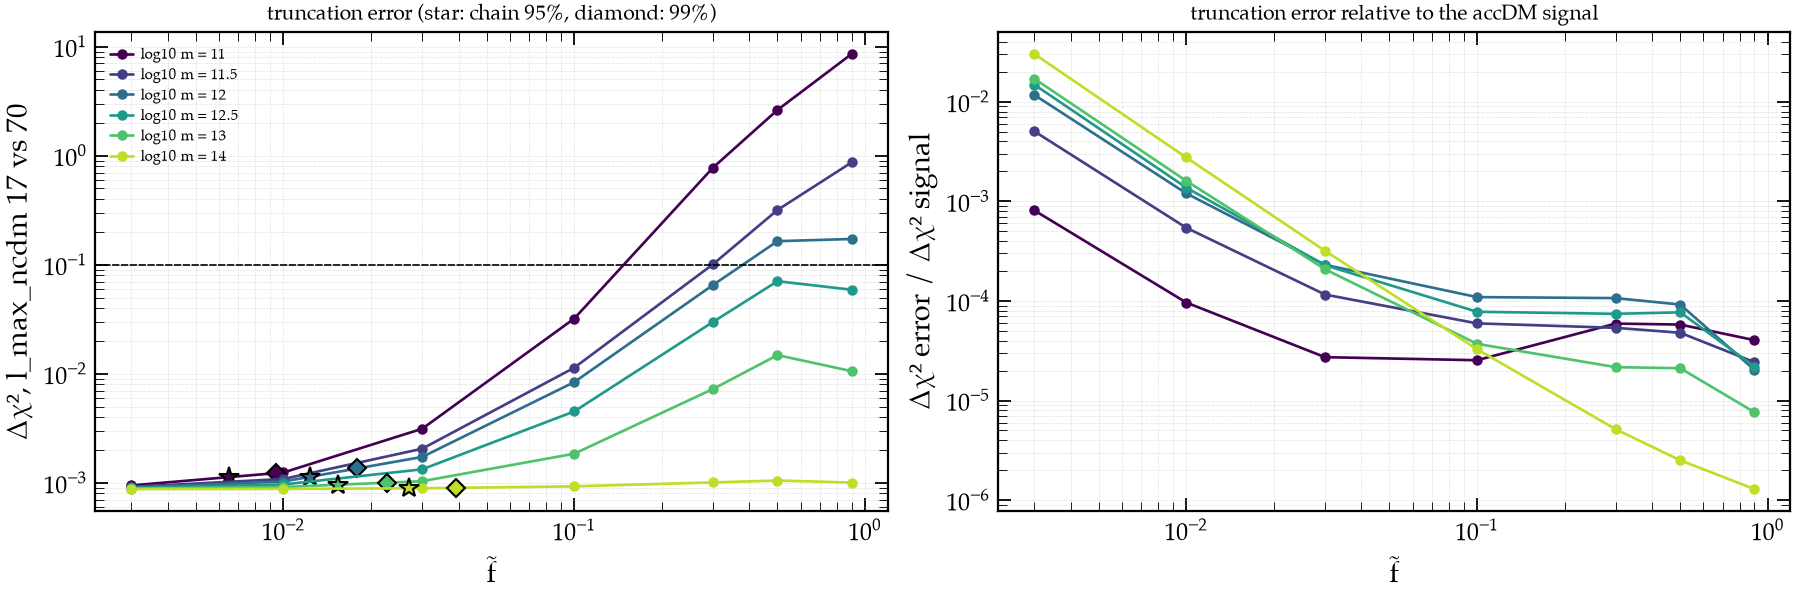

,chain 95%,chain 99%,dchi2 17 at 99%,"f > 0.1, l_max 17","box share, 17","f > 0.1, l_max 25","box share, 25","f > 0.1, l_max 35","box share, 35","f > 0.1, l_max 50","box share, 50"
log10m,,,,,,,,,,,
11.0,0.00651,0.00945,0.00123,0.148,0.852,0.2,0.800,0.282,0.718,-,0.000
11.5,-,-,-,0.298,0.701,0.409,0.590,-,0.000,-,0.000
12.0,0.0123,0.0179,0.00136,0.38,0.620,-,0.000,-,0.000,-,0.000
12.5,-,-,-,-,0.000,-,0.000,-,0.000,-,0.000
13.0,0.0154,0.0226,0.001,-,0.000,-,0.000,-,0.000,-,0.000
14.0,0.0269,0.0392,0.000901,-,0.000,-,0.000,-,0.000,-,0.000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
f = np.array(F_GRID)
for c, lm in zip(plt.cm.viridis(np.linspace(0, 0.9, len(MASSES))), MASSES):
    d17 = np.array([table.loc[(lm, ft), 'dchi2 17'] for ft in F_GRID])
    sig = np.array([table.loc[(lm, ft), 'signal'] for ft in F_GRID])
    axes[0].loglog(f, d17, 'o-', color=c, ms=4, label='log10 m = {:g}'.format(lm))
    axes[1].loglog(f, d17/sig, 'o-', color=c, ms=4)
    if lm in QUANT:
        for q, marker in zip(QUANT[lm], ('*', 'D')):
            at = np.exp(np.interp(np.log(q), np.log(f), np.log(d17)))
            axes[0].plot(q, at, marker, color=c, ms=10 if marker == '*' else 6, mec='k')
for ax in axes:
    ax.set_xlabel('f̃')
    ax.grid(alpha=0.3, which='both')
axes[0].axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
axes[0].set_ylabel('Δχ², l_max_ncdm 17 vs {}'.format(REF))
axes[1].set_ylabel('Δχ² error / Δχ² signal')
axes[0].set_title('truncation error (star: chain 95%, diamond: 99%)', fontsize=10)
axes[1].set_title('truncation error relative to the accDM signal', fontsize=10)
axes[0].legend(fontsize=7)
plt.show()


def crossing(lm, L, tol=DCHI2_TOL):
    """Smallest f_tilde on the grid (log-log interpolated) where dchi2 of l_max L exceeds tol."""
    d = np.array([table.loc[(lm, ft), 'dchi2 {}'.format(L)] for ft in F_GRID])
    above = np.nonzero(d > tol)[0]
    if len(above) == 0:
        return np.nan
    i = above[0]
    if i == 0:
        return F_GRID[0]
    x0, x1, y0, y1 = np.log(F_GRID[i - 1]), np.log(F_GRID[i]), np.log(max(d[i - 1], 1e-12)), np.log(d[i])
    return float(np.exp(x0 + (np.log(tol) - y0)*(x1 - x0)/(y1 - y0)))


rows = []
for lm in MASSES:
    row = {'log10m': lm}
    if lm in QUANT:
        row['chain 95%'], row['chain 99%'] = QUANT[lm]
        d17 = np.array([table.loc[(lm, ft), 'dchi2 17'] for ft in F_GRID])
        row['dchi2 17 at 99%'] = np.exp(np.interp(np.log(QUANT[lm][1]), np.log(f), np.log(d17)))
    for L in LMAXS:
        fc = crossing(lm, L)
        row['f > 0.1, l_max {}'.format(L)] = fc
        row['box share, {}'.format(L)] = 0.0 if np.isnan(fc) else (0.999 - fc)/0.999
    rows.append(row)
cross = pd.DataFrame(rows).set_index('log10m')
show(cross, {c: ('{:.3f}' if 'share' in c else '{:.3g}') for c in cross.columns})

## 3. Where the error sits

Ratios of `l_max_ncdm` = 17, 25, 35, 50 to 70 at three points: lensed TT, lensing potential and P_cb(z = 0).

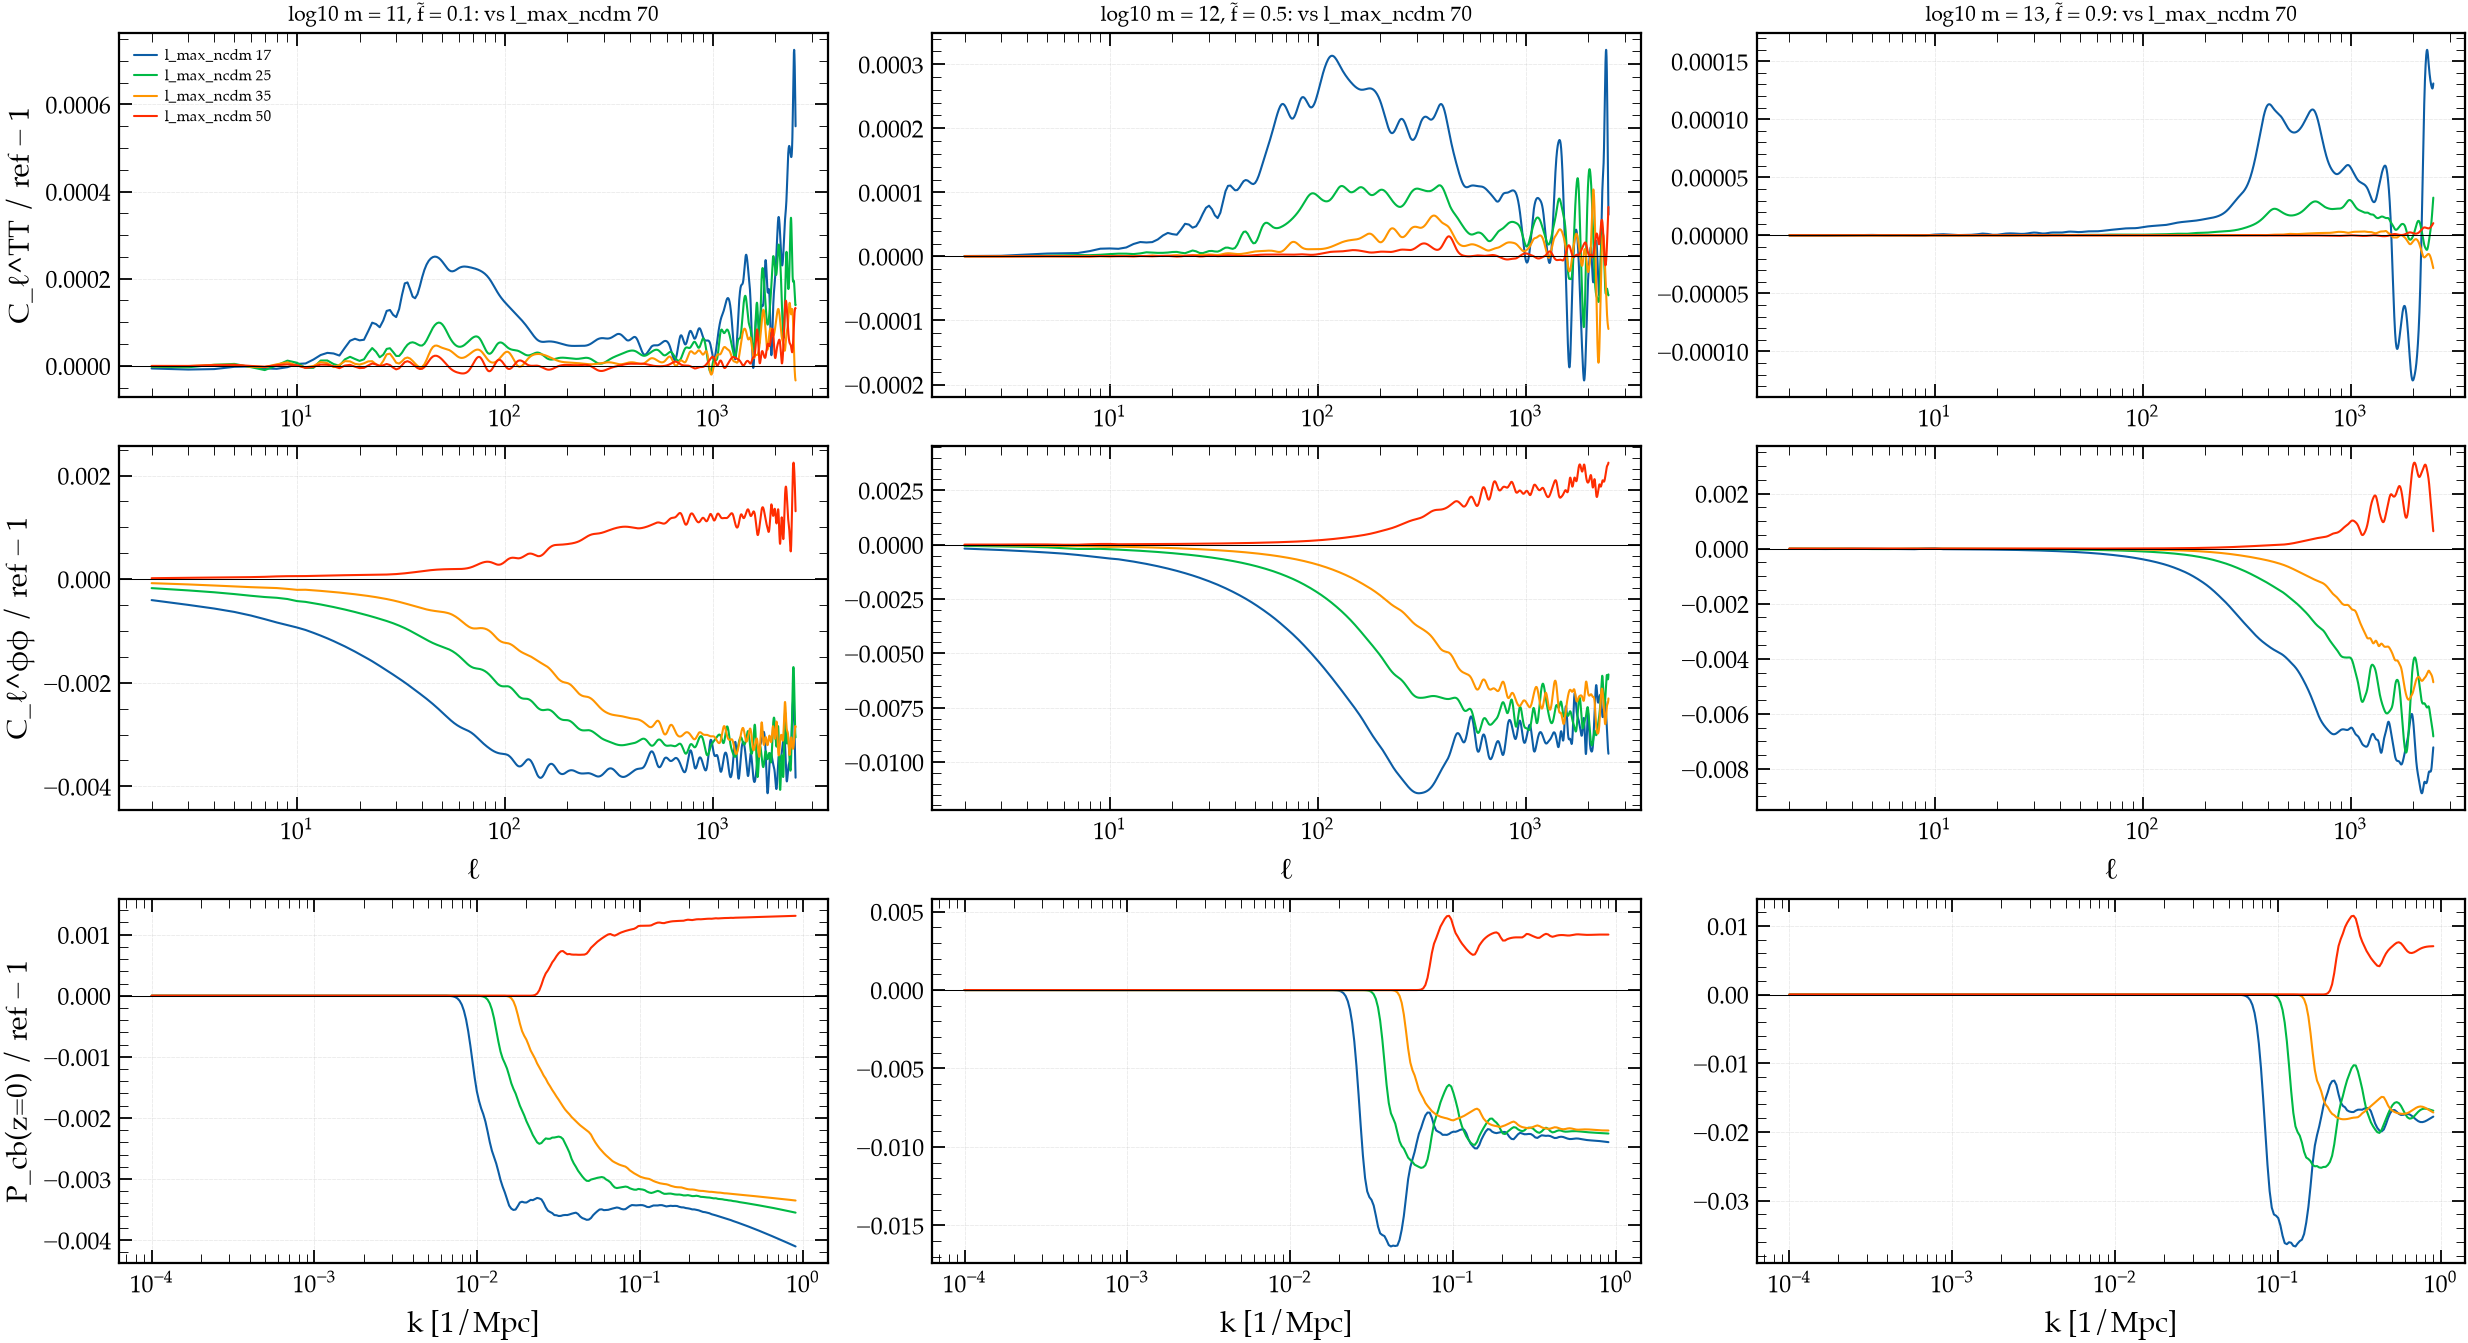

In [6]:
SHOW_POINTS = [(11, 0.1), (12, 0.5), (13, 0.9)]
fig, axes = plt.subplots(3, len(SHOW_POINTS), figsize=(5.5*len(SHOW_POINTS), 9), constrained_layout=True,
                         squeeze=False)
for j, (lm, ft) in enumerate(SHOW_POINTS):
    ref = res[(lm, ft, REF)]
    for c, L in zip(('C0', 'C1', 'C2', 'C3'), LMAXS):
        out = res[(lm, ft, L)]
        axes[0, j].semilogx(ELL, out['tt']/ref['tt'] - 1, color=c, lw=1, label='l_max_ncdm {}'.format(L))
        axes[1, j].semilogx(ELL, out['pp']/ref['pp'] - 1, color=c, lw=1)
        axes[2, j].semilogx(KK, out['pk_cb']/ref['pk_cb'] - 1, color=c, lw=1)
    axes[0, j].set_title('log10 m = {:g}, f̃ = {:g}: vs l_max_ncdm {}'.format(lm, ft, REF), fontsize=10)
    axes[1, j].set_xlabel('ℓ')
    axes[2, j].set_xlabel('k [1/Mpc]')
    for ax in axes[:, j]:
        ax.axhline(0, color='k', lw=0.5)
        ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('C_ℓ^TT / ref − 1')
axes[1, 0].set_ylabel('C_ℓ^φφ / ref − 1')
axes[2, 0].set_ylabel('P_cb(z=0) / ref − 1')
axes[0, 0].legend(fontsize=7)
plt.show()

## 4. Separate from the momentum grid?

At three points, 200 bins/decade with `l_max_ncdm` = 17 and 70. If the two errors are independent, the l_max error
(17 vs 70) is the same at 50 and 200 bins/decade, and the grid error (50 vs 200) is the same at either l_max. The
grid error at 50/decade is what s = 0.25 leaves (nb38), shown for scale.

In [7]:
GRID_POINTS = [(11, 0.1), (11, 0.5), (12, 0.5)]
gjobs = {(lm, ft, L, 200): params(lm, ft, l_max_ncdm=L, accdm_q_bins_per_decade=200)
         for lm, ft in GRID_POINTS for L in (17, REF)}
gres = dict(zip(gjobs, run_all(list(gjobs.values()))))
assert all(ok(o) for o in gres.values()), [o.get('error') for o in gres.values() if not ok(o)]
rows = []
for lm, ft in GRID_POINTS:
    r = {(L, 50): res[(lm, ft, L)] for L in (17, REF)}
    r.update({(L, 200): gres[(lm, ft, L, 200)] for L in (17, REF)})
    for label, a, b in [('l_max 17 vs 70, at 50/dec', r[(17, 50)], r[(REF, 50)]),
                        ('l_max 17 vs 70, at 200/dec', r[(17, 200)], r[(REF, 200)]),
                        ('grid 50 vs 200, at l_max 17', r[(17, 50)], r[(17, 200)]),
                        ('grid 50 vs 200, at l_max 70', r[(REF, 50)], r[(REF, 200)]),
                        ('both: 50, 17 vs 200, 70', r[(17, 50)], r[(REF, 200)])]:
        c = compare(a, b)
        rows.append({'log10m': lm, 'f_tilde': ft, 'comparison': label, 'dchi2': c['total'], 'cmb': c['cmb'],
                     'lens': c['lens'], 'max dPcb': c['dpk'], 'dsigma8_cb': c['dsigma8']})
gtab = pd.DataFrame(rows).set_index(['log10m', 'f_tilde', 'comparison'])
show(gtab, {**{c: '{:.2e}' for c in gtab.columns}, 'dsigma8_cb': '{:+.1e}'})

6 new runs in 820 s


dchi2       cmb      lens  \
log10m f_tilde comparison                                                  
11     0.1     l_max 17 vs 70, at 50/dec    3.21e-02  1.05e-02  2.16e-02   
               l_max 17 vs 70, at 200/dec   2.62e-02  4.64e-03  2.16e-02   
               grid 50 vs 200, at l_max 17  3.22e-02  3.22e-02  2.52e-05   
               grid 50 vs 200, at l_max 70  5.41e-03  5.39e-03  2.34e-05   
               both: 50, 17 vs 200, 70      5.05e-02  2.75e-02  2.31e-02   
       0.5     l_max 17 vs 70, at 50/dec    2.62e+00  2.25e+00  3.78e-01   
               l_max 17 vs 70, at 200/dec   4.83e-01  1.09e-01  3.74e-01   
               grid 50 vs 200, at l_max 17  5.74e+00  5.74e+00  1.84e-03   
               grid 50 vs 200, at l_max 70  1.11e+00  1.11e+00  1.54e-03   
               both: 50, 17 vs 200, 70      6.56e+00  6.14e+00  4.27e-01   
12     0.5     l_max 17 vs 70, at 50/dec    1.64e-01  1.01e-02  1.54e-01   
               l_max 17 vs 70, at 200/dec   1.64e-01  9.59e-03  1.54e-01   
               grid 50 vs 200, at l_max 17  3.77e-02  3.75e-02  1.88e-04   
               grid 50 vs 200, at l_max 70  3.24e-02  3.22e-02  1.85e-04   
               both: 50, 17 vs 200, 70      2.20e-01  5.55e-02  1.65e-01   

                                            max dPcb dsigma8_cb  
log10m f_tilde comparison                                        
11     0.1     l_max 17 vs 70, at 50/dec    4.10e-03   -1.7e-03  
               l_max 17 vs 70, at 200/dec   4.10e-03   -1.7e-03  
               grid 50 vs 200, at l_max 17  3.37e-04   -1.2e-04  
               grid 50 vs 200, at l_max 70  3.38e-04   -1.2e-04  
               both: 50, 17 vs 200, 70      4.34e-03   -1.9e-03  
       0.5     l_max 17 vs 70, at 50/dec    2.47e-02   -1.1e-02  
               l_max 17 vs 70, at 200/dec   2.47e-02   -1.1e-02  
               grid 50 vs 200, at l_max 17  3.81e-03   -1.8e-03  
               grid 50 vs 200, at l_max 70  3.77e-03   -1.8e-03  
               both: 50, 17 vs 200, 70      2.84e-02   -1.3e-02  
12     0.5     l_max 17 vs 70, at 50/dec    1.64e-02   -4.8e-03  
               l_max 17 vs 70, at 200/dec   1.63e-02   -4.8e-03  
               grid 50 vs 200, at l_max 17  1.69e-03   -7.7e-04  
               grid 50 vs 200, at l_max 70  1.69e-03   -7.7e-04  
               both: 50, 17 vs 200, 70      1.79e-02   -5.6e-03

## Reading the result

- **Section 1, the floor:** at `l_max_ncdm = 17` every point, including f̃ = 10⁻⁶, carries Δχ² ≈ 9·10⁻⁴ (CMB, σ8_cb
  −7·10⁻⁵). That is the neutrino hierarchy, not the daughter, and every default CLASS run has it.
- **Section 1, the daughter:** above the floor the error grows with f̃ and falls steeply with mass. It is a smooth
  suppression of P_cb above k ≈ 0.01–0.1 Mpc⁻¹ (later and smaller for colder daughters), and so of C_ℓ^φφ and the
  lensed TT peaks. At 17:
  - **10¹¹ GeV:** Δχ² 0.03 at f̃ = 0.1, 0.8 at 0.3, 2.6 at 0.5, 8.6 at 0.9 (σ8_cb −0.2%, −0.6%, −1.1%, −2.9%).
  - **10¹¹·⁵ GeV:** above 0.1 from f̃ ≈ 0.3 (0.87 at 0.9).
  - **10¹² GeV:** above 0.1 from f̃ ≈ 0.4, flat at 0.17 up to 0.9 (σ8_cb −0.5% to −1.1%), as nb37 found.
  - **10¹²·⁵ GeV and up:** below 0.1 everywhere (at most 0.07); 10¹⁴ GeV stays at the floor.
- **Section 1, the reference:** 70 against 100 is Δχ² ≤ 0.02, except σ8_cb +0.6% at 10¹¹ GeV, f̃ = 0.9.
  Convergence is not monotonic: at 50 the P_cb and C_ℓ^φφ errors change sign (+0.1 to +0.7% at high k), so treat 70
  as good to a few 10⁻³ in P_cb, not better. That is irrelevant next to the errors at 17.
- **Section 2, chains:** at each chain's 99% f̃ (10¹¹–10¹⁴ GeV) Δχ² is 0.9–1.4·10⁻³, essentially the neutrino
  floor. The warm-mass limits are not affected.
- **Section 2, training box:** at 17, Δχ² exceeds 0.1 for f̃ above 0.15 / 0.30 / 0.38 at 10¹¹ / 10¹¹·⁵ / 10¹² GeV,
  i.e. on 85% / 70% / 62% of the flat f̃ ∈ [0, 0.999] box. Those training points are biased, but by at most
  ~10⁻⁴ of their Δχ² distance from ΛCDM (10³–10⁵), and the bias is smooth and monotonic in f̃ and mass, so it gives
  the emulator nothing to mislearn near the posterior. Compare nb33/κ = 100, where the error was the signal.
- **Section 3, cost:** relative run time 1, 1.35, 1.7, 2.3, 3.1 for 17, 25, 35, 50, 70 (measured with 8 runs in
  parallel). 35 keeps Δχ² ≤ 0.1 everywhere except 10¹¹ GeV at f̃ ≳ 0.3; 50 keeps it ≤ 0.07 everywhere.
- **Section 4, against the momentum grid:** at 10¹² GeV the two errors are independent and add (l_max error 0.16 at
  50 and at 200 bins/decade; grid error 0.03-0.04 at either l_max). At 10¹¹ GeV, f̃ = 0.5 they interact in the CMB:
  the l_max error is 2.6 at 50/decade but 0.5 at 200, and the grid error left at s = 0.25 is 5.7 at l_max 17 and 1.1
  at 70 (vs 200/decade). There the grid, not the hierarchy, is the larger error. The P_cb/σ8 part of the l_max error
  (−1.1%) is the same at both grids.

**Conclusion:** `l_max_ncdm = 17` does not matter for the fixed-mass chains: at the f̃ the warm-mass posteriors
reach, its error is the 10⁻³ neutrino floor. It biases warm-daughter training points at large f̃ (≤ 10¹² GeV,
f̃ ≳ 0.15–0.4), but only far from the posterior and smoothly, so no rerun is needed. Raise it (35, or 50 for
10¹¹ GeV) only for work that uses large f̃ at warm masses directly: P(k)-based probes, profile likelihoods or plots
there. At 10¹¹ GeV and f̃ ≥ 0.3 the momentum grid would then have to be refined too, since its error is larger.